# Modelo de Clasificación de Imágenes de Basura

Carlos Iván Fonseca Mondragón | A01771689

In [21]:
# Importación de librerías
import joblib
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import ssl
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import ( Dense, Dropout, GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2 as kernel_regularizer_l2

# Evitar errores de SSL al descargar MobileNetV2
ssl._create_default_https_context = ssl._create_unverified_context

In [22]:
# Verificar si TensorFlow detecta la GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("GPU detectada:", physical_devices)
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("No se detectó GPU. Usando CPU.")

GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cargar datasets preprocesados

In [23]:
# Cargar metadatos
metadata = joblib.load("processed_datasets/metadata.pkl")

class_names = metadata["class_names"]
class_weights = metadata["class_weights"]
image_size = tuple(metadata["image_size"])
batch_size = metadata["batch_size"]
num_classes = metadata["num_classes"]

print("Metadatos cargados:")
print(f"  Clases: {class_names}")
print(f"  Pesos de clase: {class_weights}")
print(f"  Número de clases: {num_classes}")
print(f"  Tamaño de imagen: {image_size}")
print(f"  Tamaño de batch: {batch_size}")

Metadatos cargados:
  Clases: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
  Pesos de clase: {0: 1.0876190476190477, 1: 1.2903954802259887, 2: 1.2440087145969498, 3: 0.6737463126843658, 4: 1.084520417853751, 5: 1.054478301015697, 6: 0.5758951084215834, 7: 1.655072463768116, 8: 1.239956568946797}
  Número de clases: 9
  Tamaño de imagen: (224, 224)
  Tamaño de batch: 32


In [24]:
# Cargar datasets preprocesados
train_dataset_raw = tf.data.Dataset.load("processed_datasets/train")
normalized_validation_dataset = tf.data.Dataset.load("processed_datasets/validation")
normalized_test_dataset = tf.data.Dataset.load("processed_datasets/test")

print(f"Train dataset: {len(train_dataset_raw)} batches")
print(f"Validation dataset: {len(normalized_validation_dataset)} batches")
print(f"Test dataset: {len(normalized_test_dataset)} batches")

Train dataset: 108 batches
Validation dataset: 12 batches
Test dataset: 30 batches


## Data Augmentation

In [25]:
# Definir capas de augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

def augment_images(x, y):
    return data_augmentation(x, training=True), y

# Aplicar augmentation al dataset de entrenamiento
augmented_train_dataset = (
    train_dataset_raw
    .map(augment_images, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .prefetch(tf.data.AUTOTUNE)
)

## Definición del modelo

In [26]:
# Implementación de modelo preentrenado MobileNetV2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' # Usar pesos preentrenados de ImageNet
)

base_model.trainable = False

model = tf.keras.Sequential([ # Modelo secuencial "básico", MobileNetV2 se encuentra congelado y se le añaden capas densas para clasificación
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=kernel_regularizer_l2(1e-4)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


In [27]:
# Compilar modelo
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3) # Aumento en el LR para entrenamiento inicial del modelo preentrenado
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

print("\nResumen del modelo:")
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

...

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Entrenamiento

In [28]:
# Configurar callbacks
EPOCHS = 15
EPOCHS_FINE_TUNING = 55

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model_mobilenet.keras", 
        save_best_only=True, 
        monitor='val_accuracy',
        mode="max"
    ),
    
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', 
        factor=0.5, 
        patience=15, 
        min_lr=1e-7,
        mode="max",
    ),
    
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=30, 
        restore_best_weights=True,
        mode="max",

    )
]

In [29]:
# Entrenar el modelo
history_fase_1 = model.fit(
    augmented_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)

# Fine tuning, descongelamos las últimas 30 capas del modelo base y se entrena usando un LR más bajo
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # LR bajo para evitar destruir los pesos preentrenados
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_fine_tuning = model.fit(
    augmented_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=EPOCHS_FINE_TUNING,
    callbacks=callbacks,
)

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.4086 - loss: 2.5718 - val_accuracy: 0.7026 - val_loss: 1.1072 - learning_rate: 0.0010
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.5701 - loss: 1.7965 - val_accuracy: 0.7342 - val_loss: 0.9087 - learning_rate: 0.0010
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.6258 - loss: 1.4412 - val_accuracy: 0.7289 - val_loss: 0.8729 - learning_rate: 0.0010
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.6646 - loss: 1.2803 - val_accuracy: 0.7474 - val_loss: 0.9000 - learning_rate: 0.0010
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.6818 - loss: 1.1453 - val_accuracy: 0.7474 - val_loss: 0.9441 - learning_rate: 0.0010
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7081 - loss: 1.0805 - val_accuracy: 0.7711 - val_loss: 0.8499 - learning_rate: 0.0010
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.7069 - loss: 1

## Evaluación en datos de prueba

In [30]:
# Evaluar en test dataset
test_loss, test_accuracy = model.evaluate(
    normalized_test_dataset,
)

print(f"\nResultados en Test Dataset:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8109 - loss: 0.6638

Resultados en Test Dataset:
Loss: 0.6638
Accuracy: 0.8109


## Visualización de resultados

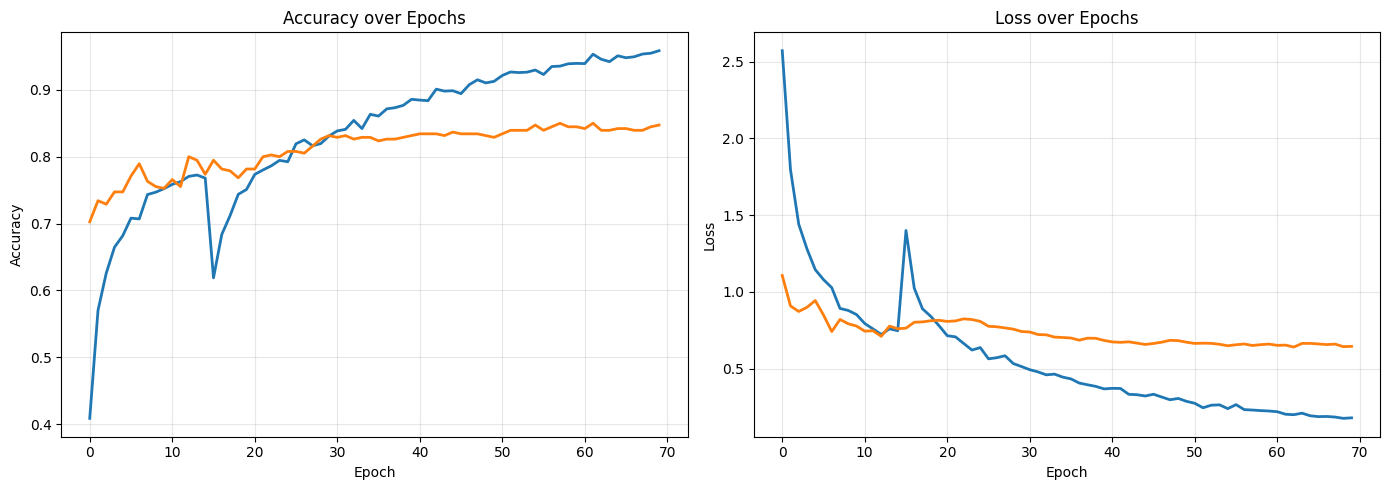


Mejor validación Accuracy: 0.8500
Mejor validación Loss: 0.6409


In [31]:
# Obtener historial de entrenamiento

history_combined = {
    'accuracy': history_fase_1.history['accuracy'] + history_fine_tuning.history['accuracy'],
    'val_accuracy': history_fase_1.history['val_accuracy'] + history_fine_tuning.history['val_accuracy'],
    'loss': history_fase_1.history['loss'] + history_fine_tuning.history['loss'],
    'val_loss': history_fase_1.history['val_loss'] + history_fine_tuning.history['val_loss'],
}

train_acc = history_combined['accuracy']
train_loss = history_combined['loss']
val_acc = history_combined['val_accuracy']
val_loss = history_combined['val_loss']

# Gráficos
plt.figure(figsize=(14, 5))

# Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMejor validación Accuracy: {max(val_acc):.4f}")
print(f"Mejor validación Loss: {min(val_loss):.4f}")

### Matriz de Confusión

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━

2026-06-06 15:58:15.945820: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


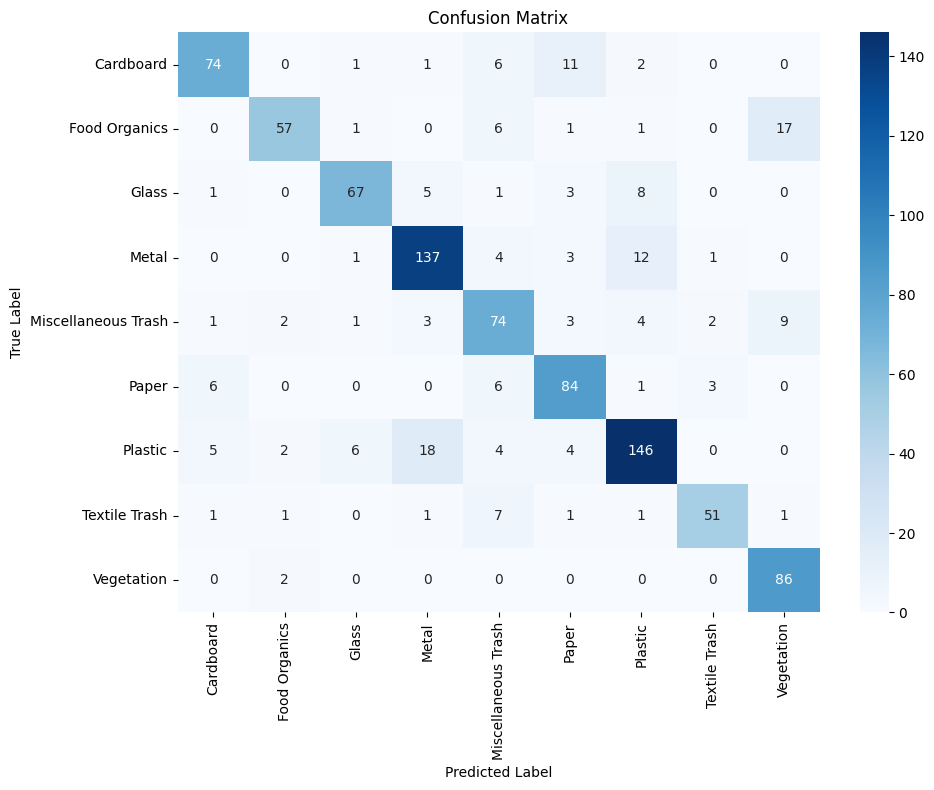

In [32]:
from sklearn.metrics import confusion_matrix, classification_report

# Obtener predicciones y etiquetas reales
y_true = []
y_pred = []

for images, labels in normalized_test_dataset:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [33]:
# Reporte de clasificación
print("\n" + "="*60)
print("                   CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))


                   CLASSIFICATION REPORT
                     precision    recall  f1-score   support

          Cardboard       0.84      0.78      0.81        95
      Food Organics       0.89      0.69      0.78        83
              Glass       0.87      0.79      0.83        85
              Metal       0.83      0.87      0.85       158
Miscellaneous Trash       0.69      0.75      0.71        99
              Paper       0.76      0.84      0.80       100
            Plastic       0.83      0.79      0.81       185
      Textile Trash       0.89      0.80      0.84        64
         Vegetation       0.76      0.98      0.86        88

           accuracy                           0.81       957
          macro avg       0.82      0.81      0.81       957
       weighted avg       0.82      0.81      0.81       957



## Guardar modelo final

In [34]:
model.save("modelo_mobilenet.keras")
print("Modelo guardado como: modelo_mobilenet.keras")
print("Mejor modelo guardado como: best_model_mobilenet.keras")

Modelo guardado como: modelo_mobilenet.keras
Mejor modelo guardado como: best_model_mobilenet.keras
